## **Layer 2 : Signal and Edge Extraction**

In [1]:
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import os
import numpy as np
import pandas as pd
import seaborn as sns
import pandas_ta as ta

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [2]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to sys.path to allow importing from pipeline
# This setup assumes the notebook is in a subdirectory like 'layers/'
current_working_dir = os.getcwd()
if os.path.basename(current_working_dir) == "layers":
    PROJECT_ROOT = os.path.abspath(os.path.join(current_working_dir, ".."))
else:
    PROJECT_ROOT = current_working_dir

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Define data path (assuming data/market_features.parquet is in project root/data)
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
PROCESSED_DATA_FILE = os.path.join(DATA_DIR, "market_features.parquet")

print(f"Project root set to: {PROJECT_ROOT}")
print(f"Attempting to load data from: {PROCESSED_DATA_FILE}")

try:
    market_data_df = pd.read_parquet(PROCESSED_DATA_FILE)
    print(f"Successfully loaded processed data from {PROCESSED_DATA_FILE}")
except FileNotFoundError:
    print(f"Error: Processed data file not found at {PROCESSED_DATA_FILE}")
    print(
        "Please ensure Layer 1 has been run and the feature pipeline in "
        "'pipeline/feature_pipeline.py' has generated the data."
    )
    market_data_df = pd.DataFrame()

# Display first few rows to confirm data loading and regime column
print("\nDataFrame Head (with regime):")
if not market_data_df.empty:
    print(market_data_df[['datetime', 'close', 'regime']].head())
else:
    print("DataFrame is empty, cannot display head.")

Project root set to: /Users/raoabdul/Documents/Development/Trading-Bot-Algo
Attempting to load data from: /Users/raoabdul/Documents/Development/Trading-Bot-Algo/data/market_features.parquet
Successfully loaded processed data from /Users/raoabdul/Documents/Development/Trading-Bot-Algo/data/market_features.parquet

DataFrame Head (with regime):
                   datetime       close                    regime
0 2026-01-22 14:43:00+00:00  249.401596                   Unknown
1 2026-01-22 14:44:00+00:00  249.729996  Ranging - Downtrend Bias
2 2026-01-22 14:45:00+00:00  249.729996  Ranging - Downtrend Bias
3 2026-01-22 14:46:00+00:00  249.115005  Ranging - Downtrend Bias
4 2026-01-22 14:47:00+00:00  249.085007  Ranging - Downtrend Bias


In [3]:
def generate_signals(df_input):
    """
    Generates more descriptive signals based on the K-Means market regimes,
    making Exit Long signals more patient.
    """
    df = df_input.copy()
    signals = pd.Series(index=df.index, dtype=str, name='signal').fillna('Neutral')

    # --- Helper features for signal confirmation (keep as is) ---
    df['rsi_5_prev'] = df['rsi_5'].shift(1) 

    # --- Entry Signal Logic ---
    # Case 1: Uptrend Impulse with positive volume momentum
    signals[(df['regime'] == 'Uptrend - Impulse') & (df['volume_zscore'] > 0.0)] = 'Enter Long'
    
    # Case 2: Accumulation with significant volume
    signals[(df['regime'] == 'Ranging - Accumulation') & (df['volume_zscore'] > 0.5)] = 'Enter Long'
    
    # Case 3: Uptrend Pullback with RSI recovery
    signals[
        (df['regime'] == 'Uptrend - Pullback') & 
        (df['rsi_5'] > df['rsi_5_prev']) &    
        (df['rsi_5'] < 50) &                   
        (df['rsi_14'] > 60)                    
    ] = 'Enter Long'
    
    # Case 4: Ranging with Uptrend Bias and neutral-to-positive volume
    signals[(df['regime'] == 'Ranging - Uptrend Bias') & (df['volume_zscore'] > 0)] = 'Enter Long'

    # --- REVISED Exit Signal Logic (More Patient) ---
    # Only exit on clear, strong reversals or high volatility
    signals[df['regime'] == 'Downtrend - Impulse'] = 'Exit Long'  # Clear trend reversal
    signals[df['regime'] == 'Volatile - Choppy'] = 'Exit Long'    # Exit on high uncertainty

    # We remove 'Downtrend - Rally', 'Ranging - Downtrend Bias', and 'Uptrend Overbought'
    # as primary Exit Long signals. These will now be handled more by the trailing stop
    # or take profit, or require a stronger counter-trend signal.

    # --- Neutral Signal Logic ---
    signals[~signals.isin(['Enter Long', 'Exit Long'])] = 'Neutral' 
    
    # Drop helper feature
    df.drop(columns=['rsi_5_prev'], inplace=True) 
    
    return signals

In [4]:
# 1. Validation check (Guard Clause)
if market_data_df.empty or 'regime' not in market_data_df.columns:
    print("Error: Layer 1 must be run first. 'market_data_df' is empty or missing 'regime'.")
else:
    # 2. Execution
    print("Applying signal generation logic...")
    market_data_df['signal'] = generate_signals(market_data_df)
    print("Signal generation complete.")

    # 3. Verification
    if 'signal' in market_data_df.columns:
        print("\n'signal' column successfully added.")
        # Dynamically select columns that actually exist to prevent KeyErrors
        display_cols = [c for c in ['datetime', 'regime', 'signal'] if c in market_data_df.columns]
        print(market_data_df[display_cols].head())

Applying signal generation logic...
Signal generation complete.

'signal' column successfully added.
                   datetime                    regime   signal
0 2026-01-22 14:43:00+00:00                   Unknown  Neutral
1 2026-01-22 14:44:00+00:00  Ranging - Downtrend Bias  Neutral
2 2026-01-22 14:45:00+00:00  Ranging - Downtrend Bias  Neutral
3 2026-01-22 14:46:00+00:00  Ranging - Downtrend Bias  Neutral
4 2026-01-22 14:47:00+00:00  Ranging - Downtrend Bias  Neutral



Signal Counts:
signal
Neutral       61
Exit Long     21
Enter Long    13
Name: count, dtype: int64

Latest data with regimes and signals:
                    datetime       close                regime      signal
85 2026-01-22 16:08:00+00:00  249.604996     Uptrend - Impulse     Neutral
86 2026-01-22 16:09:00+00:00  249.669998     Uptrend - Impulse     Neutral
87 2026-01-22 16:10:00+00:00  249.600006     Uptrend - Impulse     Neutral
88 2026-01-22 16:11:00+00:00  249.750000     Uptrend - Impulse     Neutral
89 2026-01-22 16:12:00+00:00  249.479996  Uptrend - Overbought     Neutral
90 2026-01-22 16:13:00+00:00  249.419998     Volatile - Choppy   Exit Long
91 2026-01-22 16:14:00+00:00  249.520004  Uptrend - Overbought     Neutral
92 2026-01-22 16:15:00+00:00  249.949997     Uptrend - Impulse  Enter Long
93 2026-01-22 16:16:00+00:00  249.975006     Uptrend - Impulse     Neutral
94 2026-01-22 16:17:00+00:00  249.850098     Uptrend - Impulse     Neutral


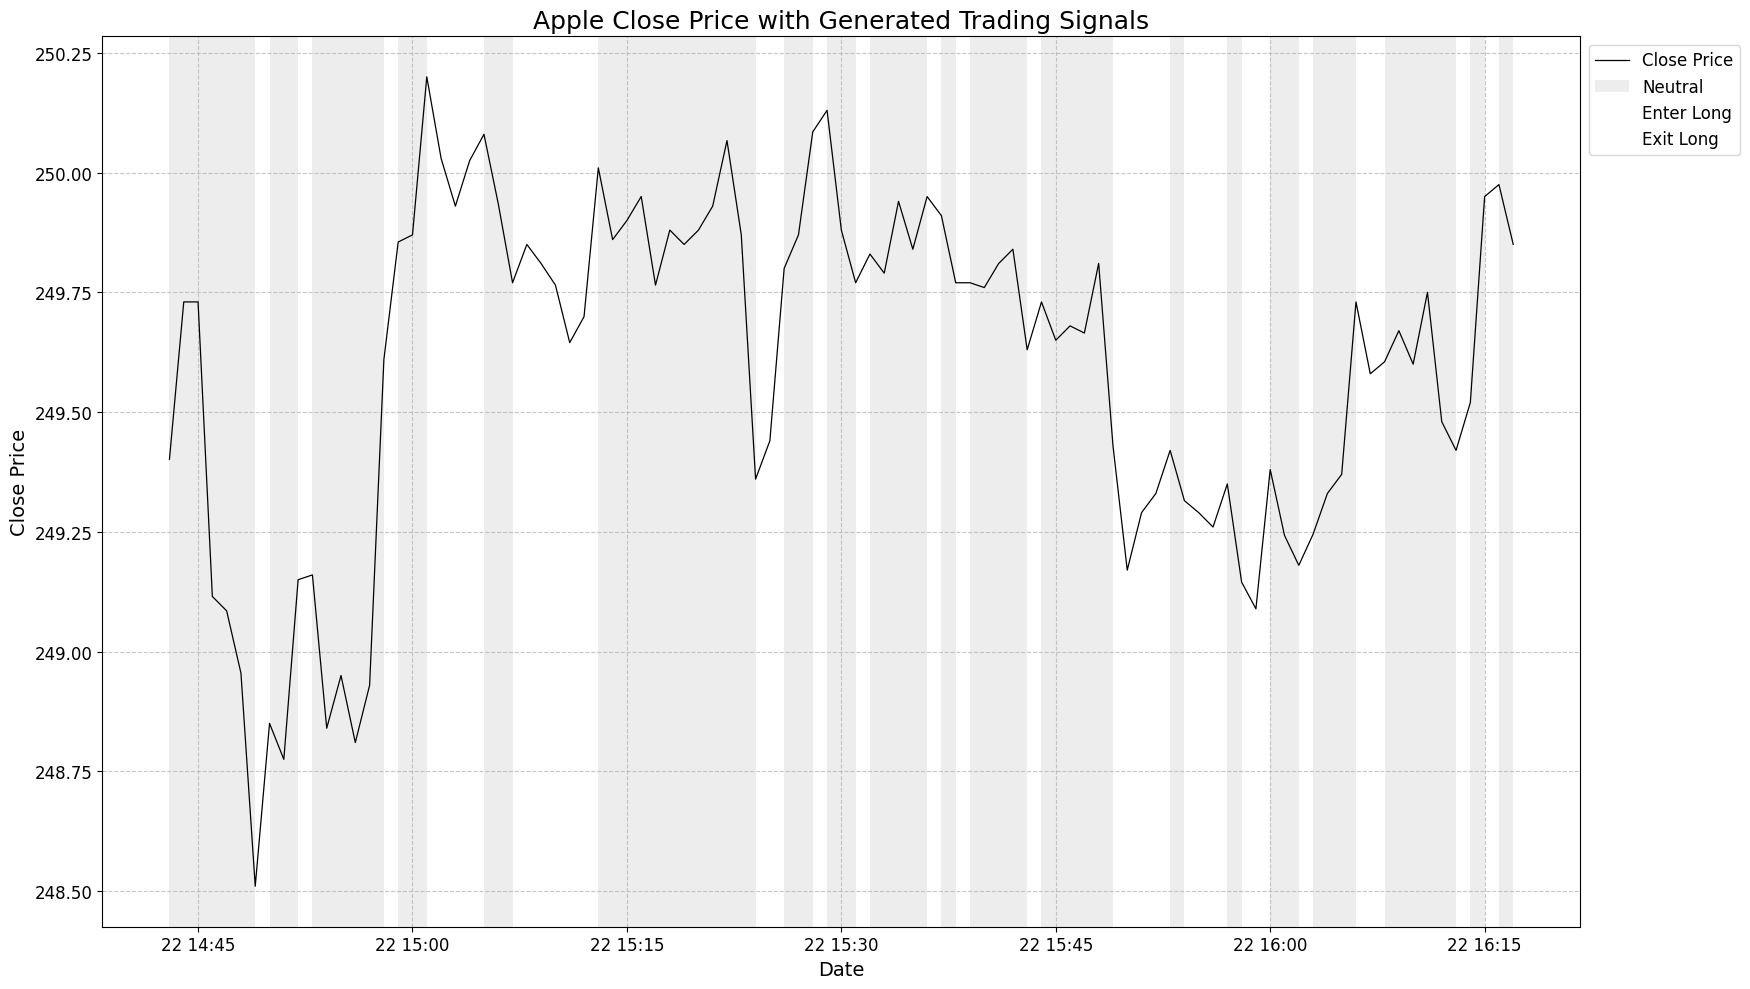

In [ ]:
if not market_data_df.empty and 'signal' in market_data_df.columns:
    print("\nSignal Counts:")
    print(market_data_df['signal'].value_counts())

    print("\nLatest data with regimes and signals:")
    print(market_data_df[['datetime', 'close', 'regime', 'signal']].tail(10))

    # Basic visualization of signals (similar to regime visualization)
    df_plot = market_data_df.dropna(subset=['signal']).copy()
    
    signal_colors = {
        'Bullish': 'green',
        'Bearish': 'red',
        'Neutral': 'lightgray'
    }

    plt.figure(figsize=(20, 10))
    ax = plt.gca()

    ax.plot(df_plot['datetime'], df_plot['close'], color='black', label='Close Price', linewidth=0.9)

    current_signal = None
    start_date = None

    for index, row in df_plot.iterrows():
        if current_signal is None:
            current_signal = row['signal']
            start_date = row['datetime']
        elif row['signal'] != current_signal:
            end_date = row['datetime']
            ax.axvspan(
                start_date, 
                end_date, 
                facecolor=signal_colors.get(current_signal, 'white'), 
                alpha=0.4,
                label=f'{current_signal}' if f'{current_signal}' not in 
                [l.get_label() for l in ax.get_legend_handles_labels()[0]] else ""
            )
            current_signal = row['signal']
            start_date = row['datetime']

    if start_date is not None and current_signal is not None:
        ax.axvspan(
            start_date, 
            df_plot['datetime'].iloc[-1], 
            facecolor=signal_colors.get(current_signal, 'white'), 
            alpha=0.4,
            label=f'{current_signal}' if f'{current_signal}' not in 
            [l.get_label() for l in ax.get_legend_handles_labels()[0]] else ""
        )

    plt.title('Nvidia Close Price with Generated Trading Signals', fontsize=18)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Close Price', fontsize=14)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout(rect=[0, 0, 0.88, 1])
    plt.show()
else:
    print("Cannot visualize signals: market_data_df is empty or 'signal' column is missing.")

## **Backtracking and Performance Analysis**

In [6]:
print("Calculating ADX as a benchmark...")
market_data_df.ta.adx(append=True)

Calculating ADX as a benchmark...


,ADX_14,ADXR_14_2,DMP_14,DMN_14
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
90,12.373652,12.852633,21.263904,21.080588
91,11.520743,12.406457,20.023007,19.850389
92,12.674005,12.523829,29.917337,16.950648
93,13.848929,12.684836,29.105006,15.976070


Generating comparison plot...


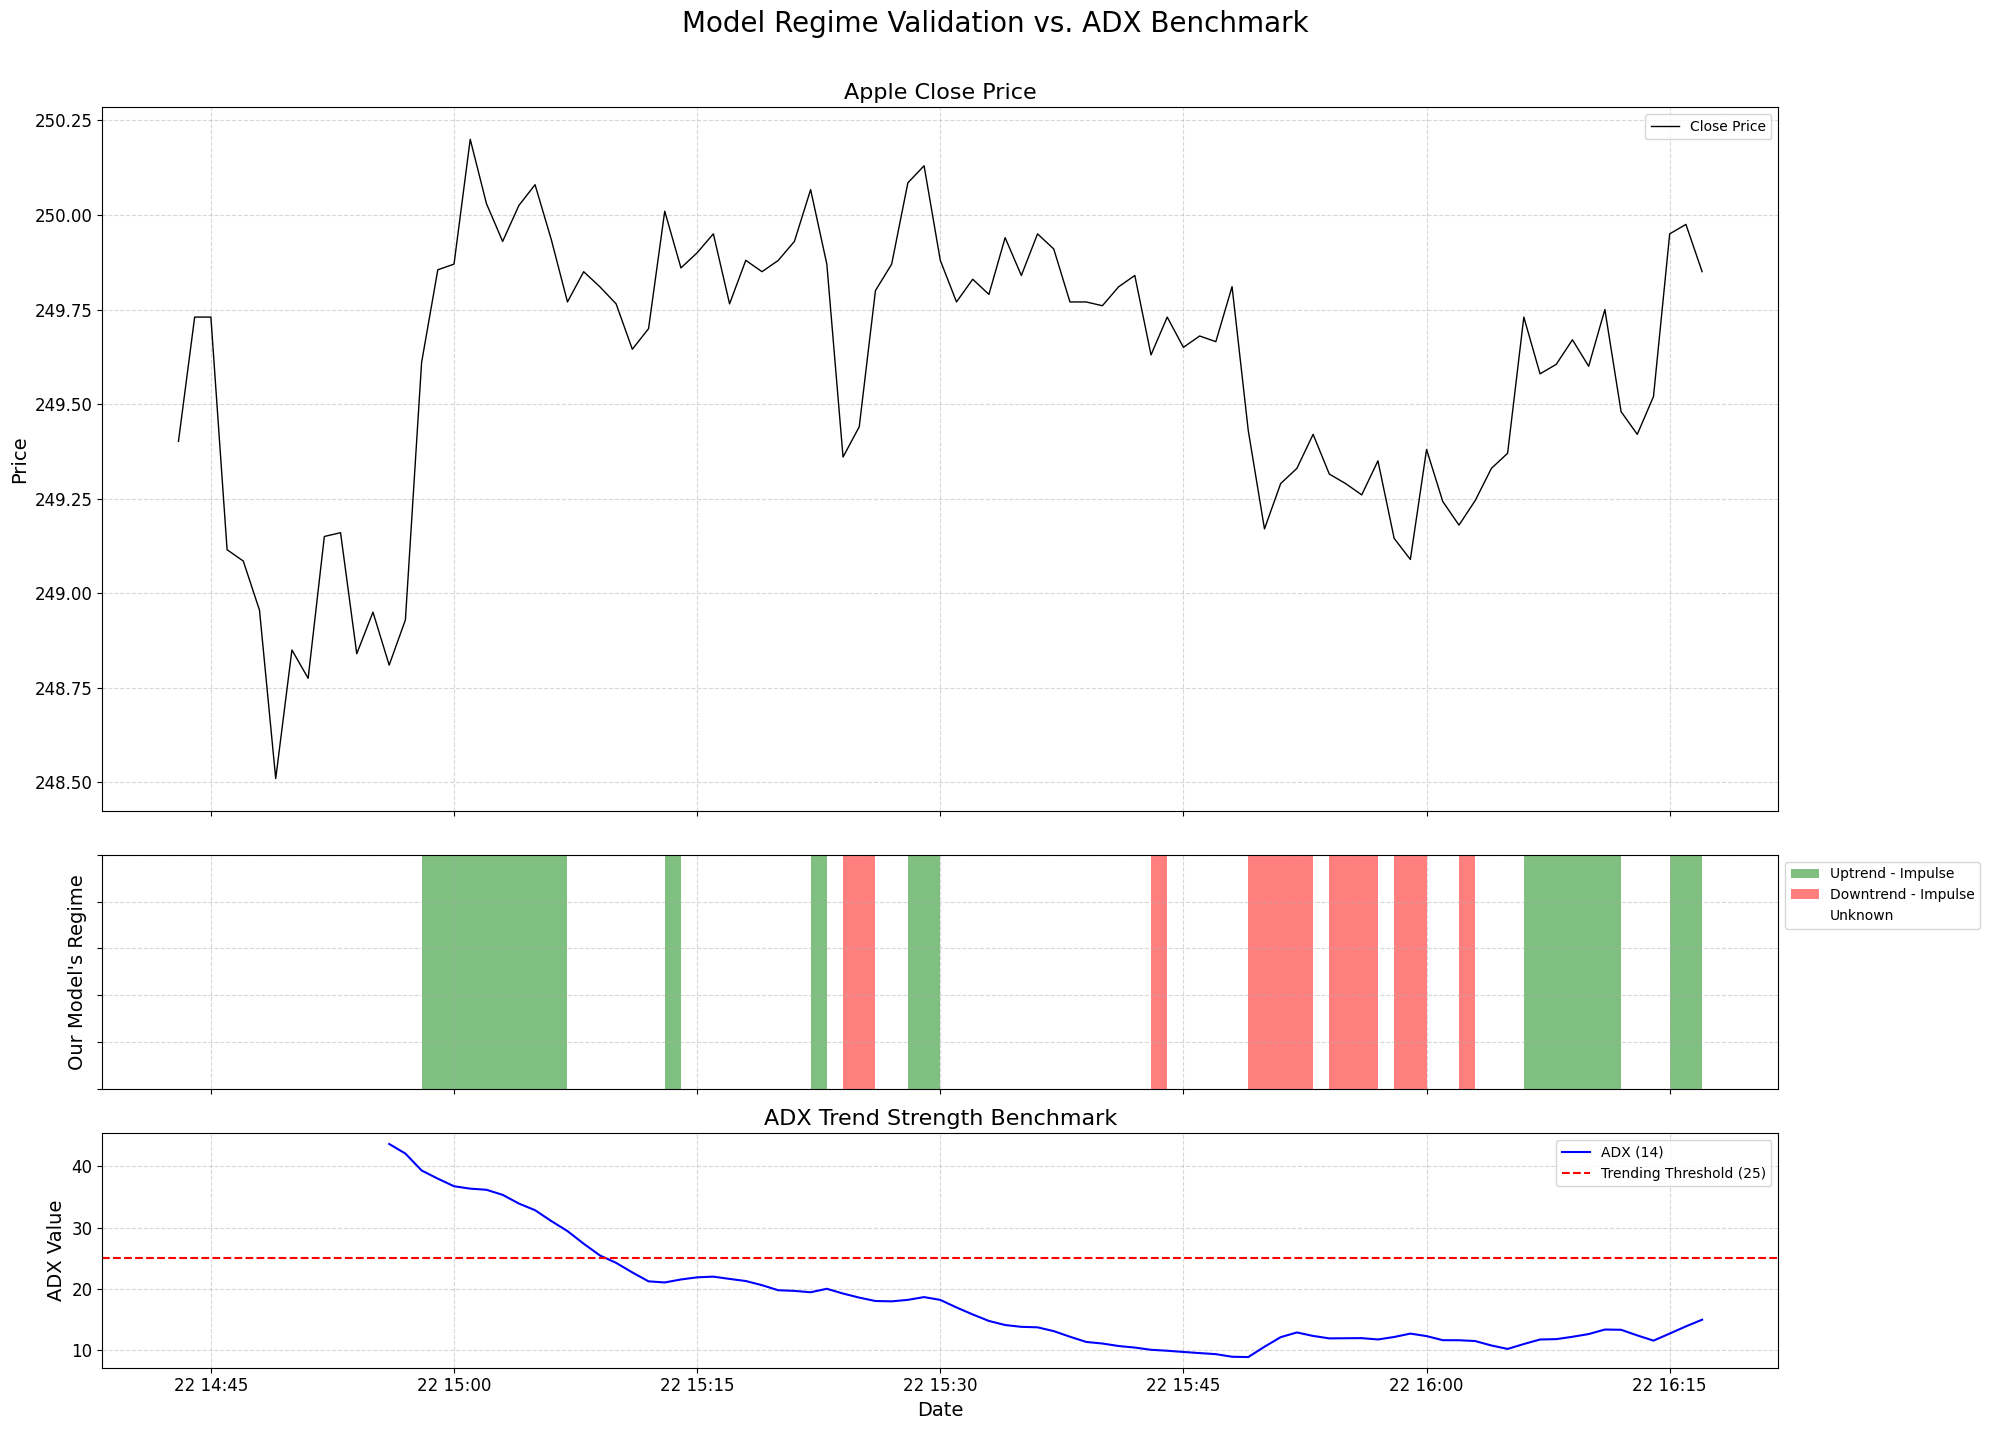

In [7]:
print("Generating comparison plot...")

# Create a figure with three subplots sharing the same X-axis
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, 
    figsize=(20, 15), 
    sharex=True, 
    gridspec_kw={'height_ratios': [3, 1, 1]}
)

fig.suptitle('Model Regime Validation vs. ADX Benchmark', fontsize=20)

# --- Plot 1: Price ---
ax1.plot(
    market_data_df['datetime'], 
    market_data_df['close'], 
    color='black', 
    label='Close Price', 
    linewidth=1
)
ax1.set_ylabel('Price', fontsize=14)
ax1.set_title('Apple Close Price', fontsize=16)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

from matplotlib.patches import Patch

df_plot = market_data_df.dropna(subset=['regime']).copy()

regime_colors = {
    'Uptrend - Impulse': 'green', 
    'Uptrend - Pullback': 'lightgreen',
    'Downtrend - Impulse': 'red', 
    'Downtrend - Rally': 'lightcoral',
    'Ranging': 'lightgray', 
    'Unknown': 'white'
}

current_regime = None
start_date = None

# Loop to draw vertical spans for each regime period
for index, row in df_plot.iterrows():
    if current_regime is None or row['regime'] != current_regime:
        if start_date is not None:
            ax2.axvspan(
                start_date, 
                row['datetime'], 
                facecolor=regime_colors.get(current_regime, 'white'), 
                alpha=0.5
            )
        current_regime = row['regime']
        start_date = row['datetime']

# Draw the final span for the last observed regime
if start_date is not None:
    ax2.axvspan(
        start_date, 
        df_plot['datetime'].iloc[-1], 
        facecolor=regime_colors.get(current_regime, 'white'), 
        alpha=0.5
    )

ax2.set_ylabel("Our Model's Regime", fontsize=14)
ax2.set_yticklabels([])  # Hide the y-axis ticks since the colors represent the data
ax2.grid(True, linestyle='--', alpha=0.5)

# Create custom legend for regimes using Matplotlib Patches
legend_elements = [
    Patch(facecolor=color, alpha=0.5, label=regime) 
    for regime, color in regime_colors.items() 
    if regime in df_plot['regime'].unique()
]
ax2.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

# --- Plot 3: ADX Benchmark ---
ax3.plot(
    market_data_df['datetime'], 
    market_data_df['ADX_14'], 
    label='ADX (14)', 
    color='blue'
)

# Add a horizontal line at 25, the common threshold for a "trending" market
ax3.axhline(25, color='red', linestyle='--', label='Trending Threshold (25)')

ax3.set_ylabel('ADX Value', fontsize=14)
ax3.set_xlabel('Date', fontsize=14)
ax3.set_title('ADX Trend Strength Benchmark', fontsize=16)
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.5)

# Adjust layout to prevent title overlap and provide room for labels
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [8]:
def score_regime_classifier(df, adx_threshold=25):
    """
    Compares the model's regime classifications (Trending/Ranging)
    against an ADX benchmark numerically.

    Args:
        df (pd.DataFrame): DataFrame containing 'regime' and 'ADX_14' columns.
        adx_threshold (int): The ADX value above which a market is considered trending.

    Returns:
        dict: A dictionary of performance metrics.
    """
    # 1. Ensure necessary columns exist and drop NaNs for comparison
    df_comp = df.dropna(subset=['regime', 'ADX_14']).copy()

    if df_comp.empty:
        print("Warning: DataFrame is empty after dropping NaNs, cannot compute scores.")
        return {}

    # 2. Define ADX Benchmark States
    df_comp['adx_trending'] = df_comp['ADX_14'] >= adx_threshold

    # 3. Define Our Model's States
    # Any 'Uptrend' or 'Downtrend' regime from our model is considered 'trending'
    trending_regimes = [
        'Uptrend - Impulse', 'Uptrend - Pullback',
        'Downtrend - Impulse', 'Downtrend - Rally'
    ]
    df_comp['model_trending'] = df_comp['regime'].isin(trending_regimes)

    # 4. Calculate Confusion Matrix Metrics
    # TP: Model says trending, ADX says trending
    tp = df_comp[(df_comp['model_trending'] == True) & (df_comp['adx_trending'] == True)].shape[0]
    
    # FP: Model says trending, ADX says ranging
    fp = df_comp[(df_comp['model_trending'] == True) & (df_comp['adx_trending'] == False)].shape[0]
    
    # FN: Model says ranging, ADX says trending
    fn = df_comp[(df_comp['model_trending'] == False) & (df_comp['adx_trending'] == True)].shape[0]
    
    # TN: Model says ranging, ADX says ranging
    tn = df_comp[(df_comp['model_trending'] == False) & (df_comp['adx_trending'] == False)].shape[0]

    total_samples = tp + fp + fn + tn

    if total_samples == 0:
        print("Warning: No samples for comparison.")
        return {}

    # 5. Calculate Performance Metrics
    accuracy = (tp + tn) / total_samples
    
    # Precision: When our model says trending, how often is it right?
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    # Recall: Of all actual trending periods, how many did our model catch?
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # F1-Score: Harmonic mean of precision and recall
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    # Specificity: When ADX says ranging, how often does our model correctly identify it?
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    metrics = {
        "True Positives (Model=Trend, ADX=Trend)": tp,
        "False Positives (Model=Trend, ADX=Range)": fp,
        "False Negatives (Model=Range, ADX=Trend)": fn,
        "True Negatives (Model=Range, ADX=Range)": tn,
        "Total Samples": total_samples,
        "Accuracy": accuracy,
        "Precision (Trending)": precision,
        "Recall (Trending)": recall,
        "F1-Score (Trending)": f1_score,
        "Specificity (Ranging)": specificity,
    }

    return metrics

# --- Apply the Scoring Function ---
print("\n--- Regime Classifier Performance Metrics (vs. ADX Benchmark) ---")
# Assuming market_data_df is defined elsewhere in your script
performance_metrics = score_regime_classifier(market_data_df)

if performance_metrics:
    for metric, value in performance_metrics.items():
        if isinstance(value, float):
            print(f"{metric}: {value:.2%}")  # Format as percentage
        else:
            print(f"{metric}: {value}")


--- Regime Classifier Performance Metrics (vs. ADX Benchmark) ---
True Positives (Model=Trend, ADX=Trend): 9
False Positives (Model=Trend, ADX=Range): 26
False Negatives (Model=Range, ADX=Trend): 5
True Negatives (Model=Range, ADX=Range): 42
Total Samples: 82
Accuracy: 62.20%
Precision (Trending): 25.71%
Recall (Trending): 64.29%
F1-Score (Trending): 36.73%
Specificity (Ranging): 61.76%


### **Save dataframe**

In [9]:
# Define the new file path for the data that now includes signals
SIGNALS_DATA_FILE = os.path.join(DATA_DIR, "market_data_signals.parquet")

if not market_data_df.empty and 'signal' in market_data_df.columns:
    try:
        # Save the DataFrame (including features, regimes, and signals) to a new Parquet file
        market_data_df.to_parquet(SIGNALS_DATA_FILE, index=False)
        print(f"\nSuccessfully saved DataFrame with signals to: {SIGNALS_DATA_FILE}")
    except Exception as e:
        print(f"\nAn error occurred while saving the file: {e}")
else:
    print("\nCannot save file: DataFrame is empty or 'signal' column is missing.")


Successfully saved DataFrame with signals to: /Users/raoabdul/Documents/Development/Trading-Bot-Algo/data/market_data_signals.parquet
